In [2]:
#import required packages and classes
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn import svm
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import pickle
import os
from sklearn.ensemble import AdaBoostClassifier
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt   
import warnings
warnings.filterwarnings('ignore')

In [3]:
#loading & displaying RT_IOT2022 intrusion detection dataset
dataset = pd.read_csv("Dataset/RT_IOT2022.csv")
dataset

,no,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30453,1995,4835,21,tcp,-,0.000004,1,1,1,0,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,64,0,64,DOS_SYN_Hping
30454,1996,4836,21,tcp,-,0.000004,1,1,1,0,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,64,0,64,DOS_SYN_Hping
30455,1997,4837,21,tcp,-,0.000004,1,1,1,0,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,64,0,64,DOS_SYN_Hping
30456,1998,4838,21,tcp,-,0.000004,1,1,1,0,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,64,0,64,DOS_SYN_Hping


In [4]:
#finding sum of missing values
dataset.isnull().sum()

NameError: name 'dataset' is not defined

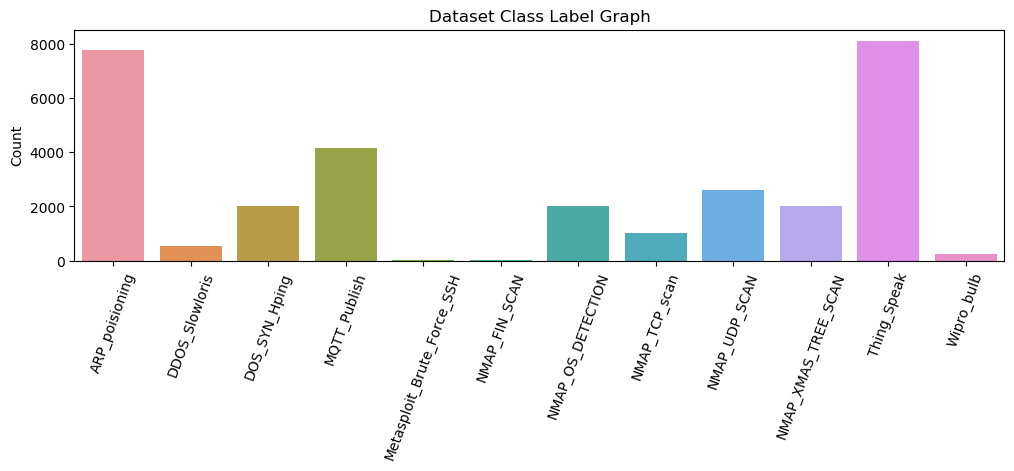

In [5]:
#finding & plotting graph of different review classes available in dataset
labels = np.unique(dataset['Attack_type'])
names, count = np.unique(dataset['Attack_type'].ravel(), return_counts = True)
plt.figure(figsize = (12, 3)) 
sns.barplot(x=labels, y=count)
plt.title("Dataset Class Label Graph")
plt.ylabel("Count")
plt.xticks(rotation=70)
plt.show()

In [5]:
#Attacks % Occured on different protocols
data = dataset.groupby('proto')['Attack_type'].count().reset_index(name="Count")
plt.pie(data['Count'], labels = data['proto'], autopct='%.0f%%')
plt.title("Attacks % Occured on Different Protocols")
plt.show()

NameError: name 'dataset' is not defined

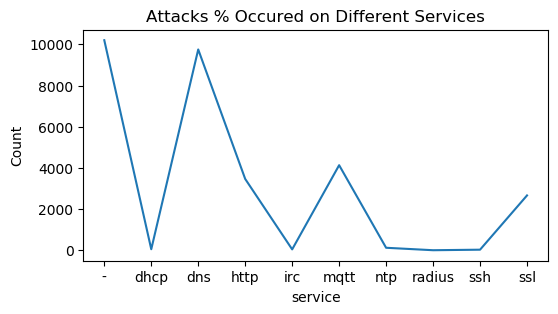

In [7]:
#Attacks % Occured on different services
data = dataset.groupby('service')['Attack_type'].count().reset_index(name="Count")
plt.figure(figsize=[6,3])
sns.lineplot(x=data['service'], y=data['Count'])
plt.title("Attacks % Occured on Different Services")
plt.show()

In [6]:
#dataset processing like non-numeric data encoding to numeric values and then replace missing values with mean
label_encoder = []
columns = dataset.columns
types = dataset.dtypes.values
for j in range(len(types)):#loop and check each column for non-numeric values
    name = types[j]
    if name == 'object': #finding column with object type
        le = LabelEncoder()
        dataset[columns[j]] = pd.Series(le.fit_transform(dataset[columns[j]].astype(str)))#encode all str columns to numeric
        label_encoder.append([columns[j], le])
dataset.fillna(dataset.mean(), inplace = True)#replace missing values with mean
dataset

NameError: name 'dataset' is not defined

In [9]:
#dataset features normalization
Y = dataset['Attack_type'].ravel()#extract attack column as the target class value
Y = Y.astype('int')
dataset.drop(['no', 'Attack_type'], axis = 1,inplace=True)#remove irrelevant columns
X = dataset.values
scaler = MinMaxScaler(feature_range = (0, 1))
X = scaler.fit_transform(X)#normalize training X features
print("Normalized Training Features = "+str(X))

Normalized Training Features = [[5.90822969e-01 2.87968924e-02 5.00000000e-01 ... 9.80239567e-01
  4.09658961e-01 7.66002899e-03]
 [7.81453412e-01 2.87968924e-02 5.00000000e-01 ... 9.80239567e-01
  4.09658961e-01 7.66002899e-03]
 [6.83937903e-01 2.87968924e-02 5.00000000e-01 ... 9.80239567e-01
  4.09658961e-01 7.66002899e-03]
 ...
 [7.39082602e-02 3.21154934e-04 5.00000000e-01 ... 9.76577401e-04
  0.00000000e+00 9.76577401e-04]
 [7.39235400e-02 3.21154934e-04 5.00000000e-01 ... 9.76577401e-04
  0.00000000e+00 9.76577401e-04]
 [7.39388198e-02 3.21154934e-04 5.00000000e-01 ... 9.76577401e-04
  0.00000000e+00 9.76577401e-04]]


In [10]:
#split dataset features into train (80% & test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
print("Dataset Split Details")
print("80% dataset features used to train algorithms : "+str(X_train.shape[0]))
print("20% dataset features used to test algorithms : "+str(X_test.shape[0]))
data = np.load("model/data.npy", allow_pickle=True)
X_train, X_test, y_train, y_test = data

Dataset Split Details
80% dataset features used to train algorithms : 24366
20% dataset features used to test algorithms : 6092


In [11]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

In [12]:
#function to evaluate model
def modelEvaluation(algorithm, testY, predict):
    p = round(precision_score(testY, predict,average='macro') * 100, 3)
    r = round(recall_score(testY, predict,average='macro') * 100, 3)
    f = round(f1_score(testY, predict,average='macro') * 100, 3)
    a = round(accuracy_score(testY,predict)*100, 3)
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  : "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FSCORE    : "+str(f))
    conf_matrix = confusion_matrix(testY, predict)
    fig, axs = plt.subplots(1,2,figsize=(12, 5))
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g", ax=axs[0]);
    ax.set_ylim([0,len(labels)])
    axs[0].set_title(algorithm+" Confusion matrix") 

    random_probs = [0 for i in range(len(testY))]
    p_fpr, p_tpr, _ = roc_curve(testY, random_probs, pos_label=10)
    plt.plot(p_fpr, p_tpr, linestyle='--', color='orange',label="True classes")
    ns_fpr, ns_tpr, _ = roc_curve(testY, predict, pos_label=10)
    axs[1].plot(ns_fpr, ns_tpr, linestyle='--', label='Predicted Classes')
    axs[1].set_title(algorithm+" ROC AUC Curve")
    axs[1].set_xlabel('False Positive Rate')
    axs[1].set_ylabel('True Positive rate')
    plt.show()

KNN Accuracy  : 98.457
KNN Precision : 97.427
KNN Recall    : 96.436
KNN FSCORE    : 96.903


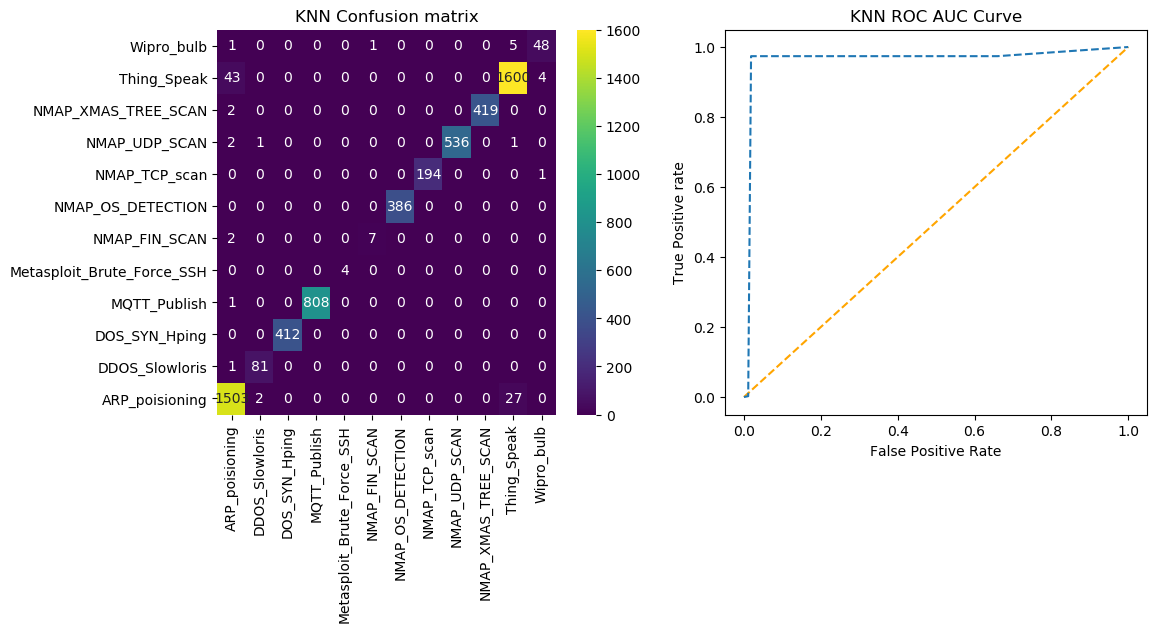

In [13]:
#train KNN algorithm on 80% training features and then apply trained model on 20% test to calculate prediction accuracy
knn_cls = KNeighborsClassifier(n_neighbors=5, weights='uniform', algorithm='auto', p=2)
#train model on training features
knn_cls.fit(X_train, y_train)
#call this function to predict on test data
predict = knn_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("KNN", y_test, predict)

SVM Accuracy  : 93.828
SVM Precision : 86.511
SVM Recall    : 84.287
SVM FSCORE    : 85.165


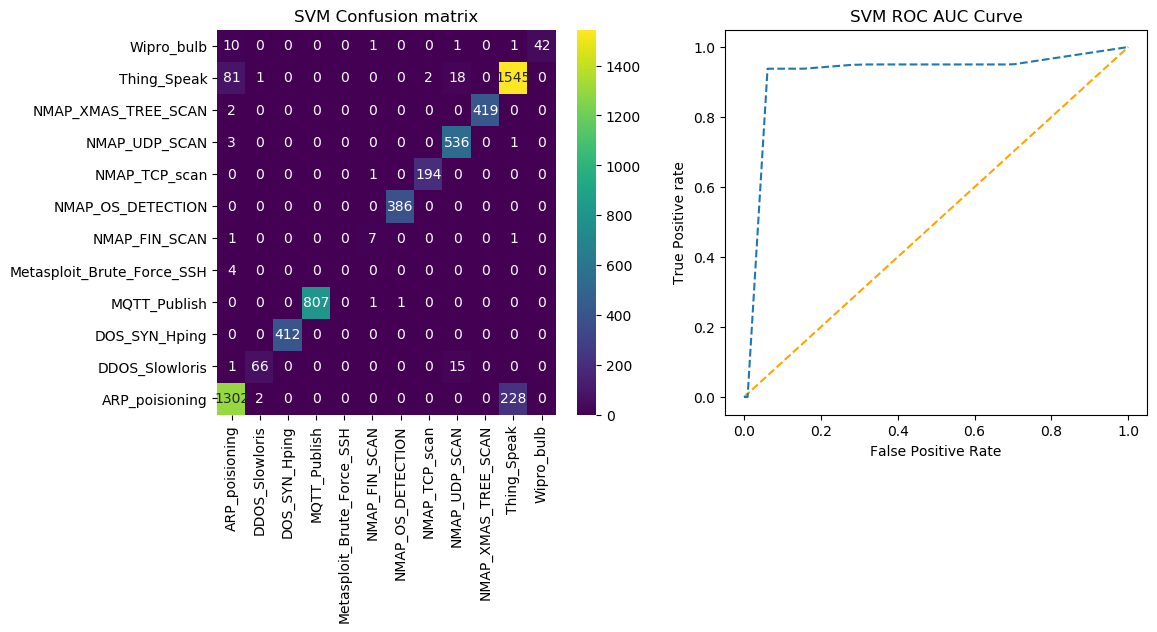

In [14]:
#train SVM algorithm on 80% training features and then apply trained model on 20% test to calculate prediction accuracy
svm_cls = svm.SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42)
#train model on training features
svm_cls.fit(X_train, y_train)
#call this function to predict on test data
predict = svm_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("SVM", y_test, predict)

Decision Tree Accuracy  : 98.9
Decision Tree Precision : 95.181
Decision Tree Recall    : 97.429
Decision Tree FSCORE    : 95.696


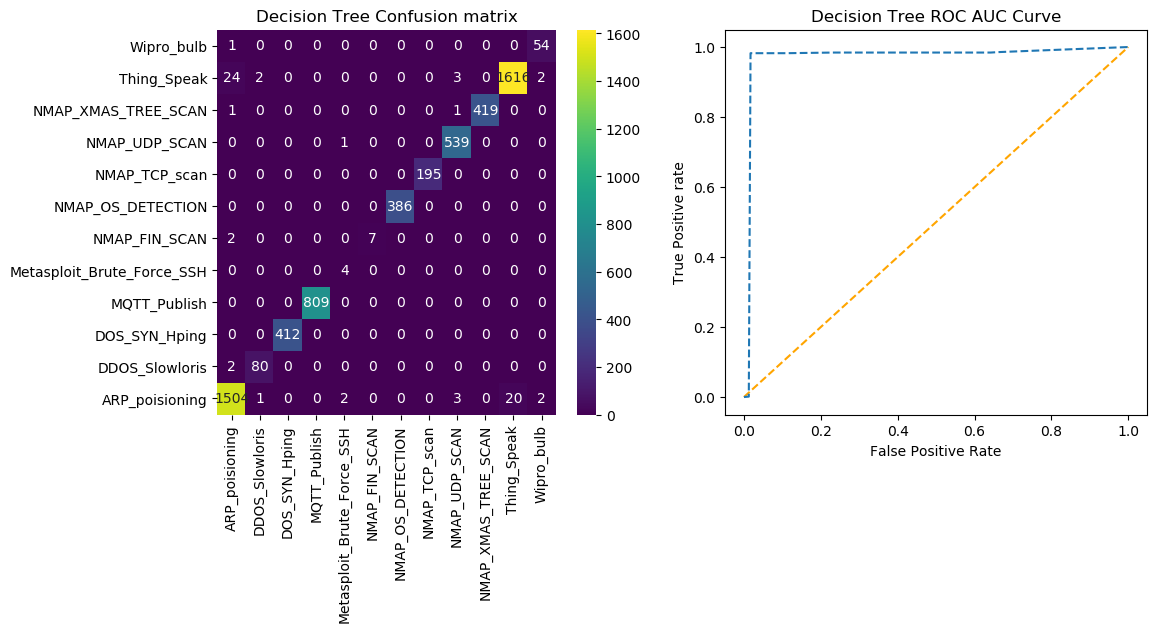

In [15]:
#train decision tree algorithm on 80% training features and then apply trained model on 20% test to calculate prediction accuracy
dt_cls = DecisionTreeClassifier(criterion='gini', splitter='best', random_state=42)
#train model on training features
dt_cls.fit(X_train, y_train)
#call this function to predict on test data
predict = dt_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("Decision Tree", y_test, predict)

Gradient Boosting Accuracy  : 98.949
Gradient Boosting Precision : 89.615
Gradient Boosting Recall    : 90.646
Gradient Boosting FSCORE    : 90.03


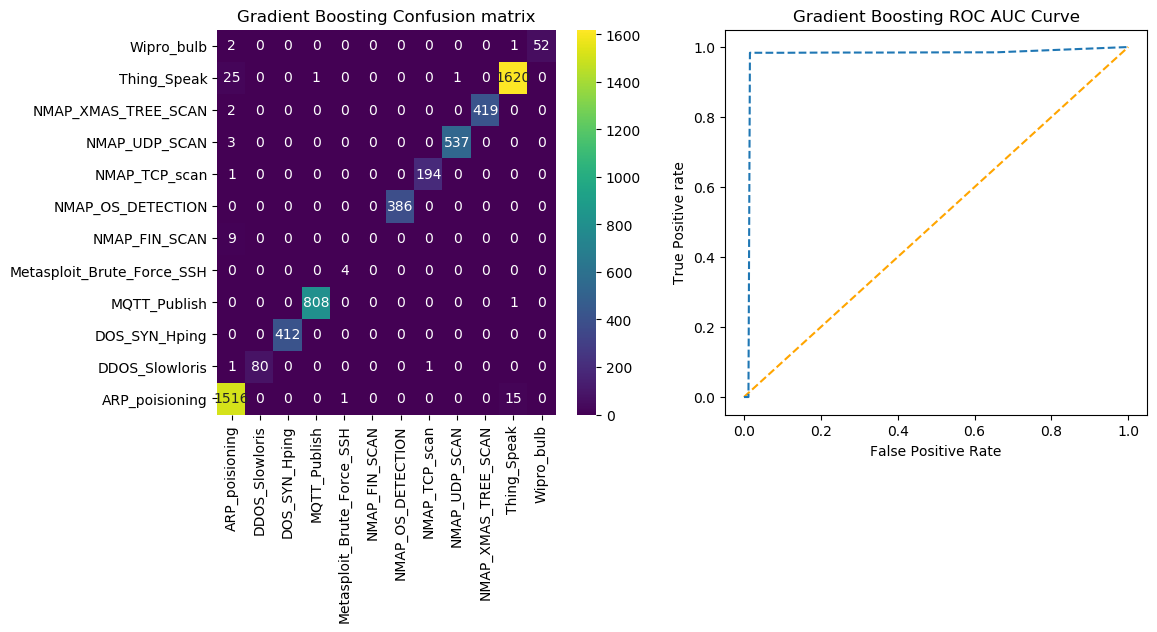

In [16]:
#train Gradient Boosting algorithm on 80% training features and then apply trained model on 20% test to calculate prediction accuracy
gb_cls = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, subsample=1.0, random_state=42)
#train model on training features
if os.path.exists("model/gb.pckl"):
    f = open('model/gb.pckl', 'rb')
    gb_cls = pickle.load(f)
    f.close() 
else:
    gb_cls.fit(X_train, y_train)
    f = open('model/gb.pckl', 'wb')
    pickle.dump(gb_cls, f)
    f.close()  
#call this function to predict on test data
predict = gb_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("Gradient Boosting", y_test, predict)

XGBoost Accuracy  : 98.949
XGBoost Precision : 89.615
XGBoost Recall    : 90.646
XGBoost FSCORE    : 90.03


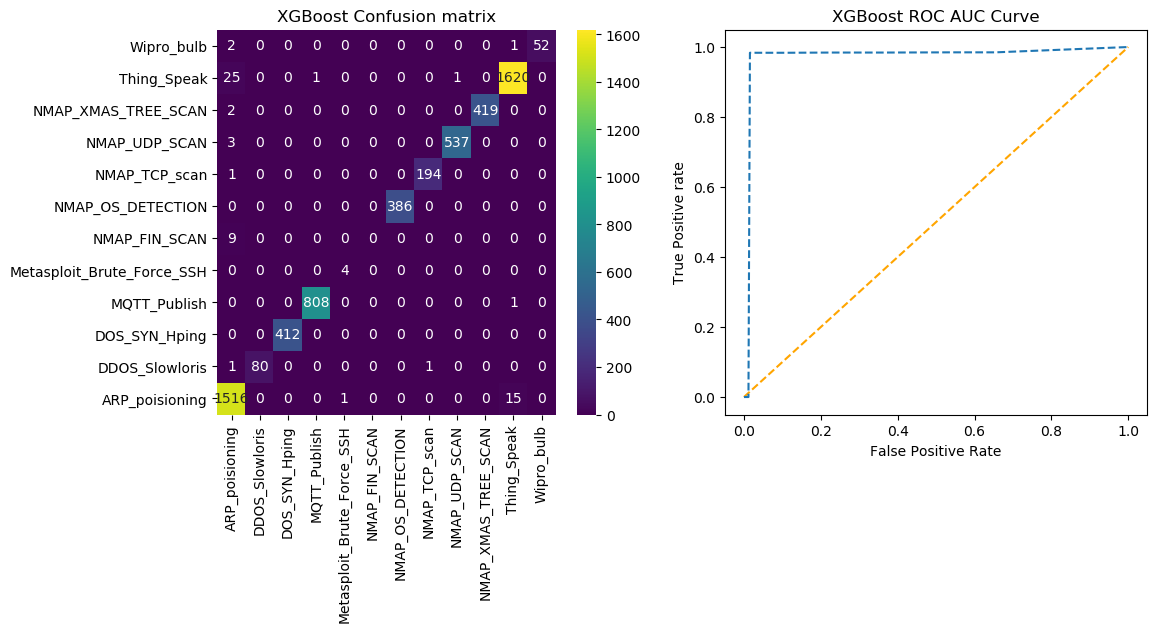

In [17]:
#train XGBoost algorithm on 80% training features and then apply trained model on 20% test to calculate prediction accuracy
xg_cls = XGBClassifier(n_estimators=100, learning_rate=0.1, min_child_weight=1.0, random_state=42)
#train model on training features
if os.path.exists("model/xg.pckl"):
    f = open('model/xg.pckl', 'rb')
    xg_cls = pickle.load(f)
    f.close() 
else:
    xg_cls.fit(X_train, y_train)
    f = open('model/xg.pckl', 'wb')
    pickle.dump(gb_cls, f)
    f.close()   
#call this function to predict on test data
predict = xg_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("XGBoost", y_test, predict)

Random Forest Accuracy  : 99.311
Random Forest Precision : 97.91
Random Forest Recall    : 97.551
Random Forest FSCORE    : 97.521


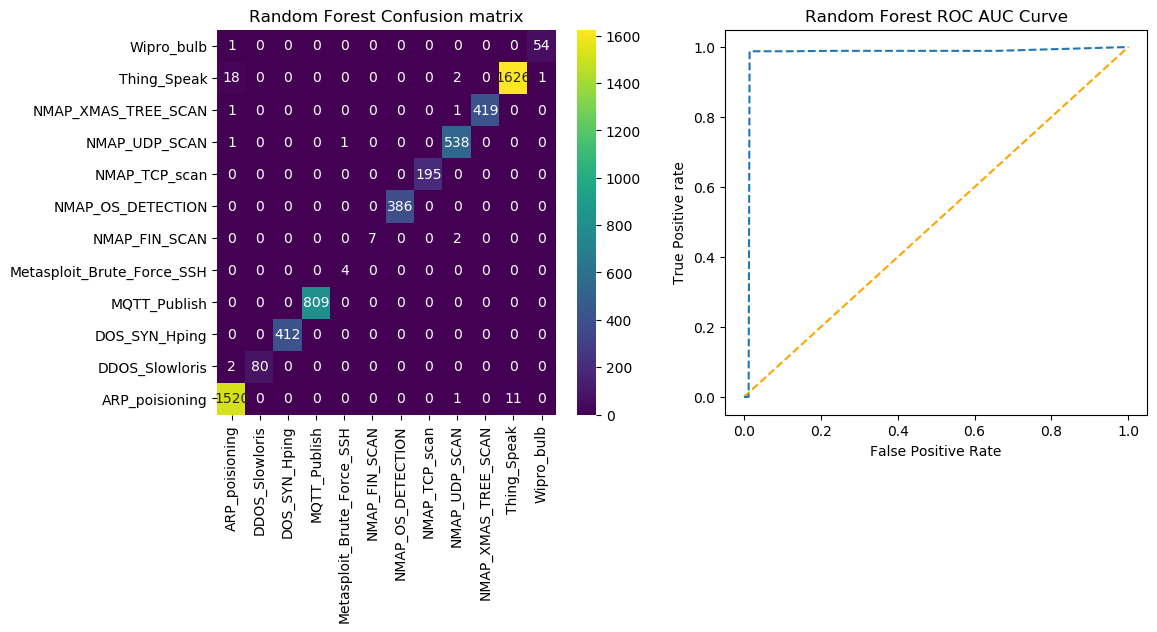

In [20]:
#train Random Forest algorithm on 80% training features and then apply trained model on 20% test to calculate prediction accuracy
rf_cls = RandomForestClassifier(n_estimators=100, criterion='gini', random_state=42)
#train model on training features
rf_cls.fit(X_train, y_train)
#call this function to predict on test data
predict = rf_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("Random Forest", y_test, predict)

Extremely Randomized Trees Accuracy  : 99.425
Extremely Randomized Trees Precision : 96.882
Extremely Randomized Trees Recall    : 97.916
Extremely Randomized Trees FSCORE    : 97.005


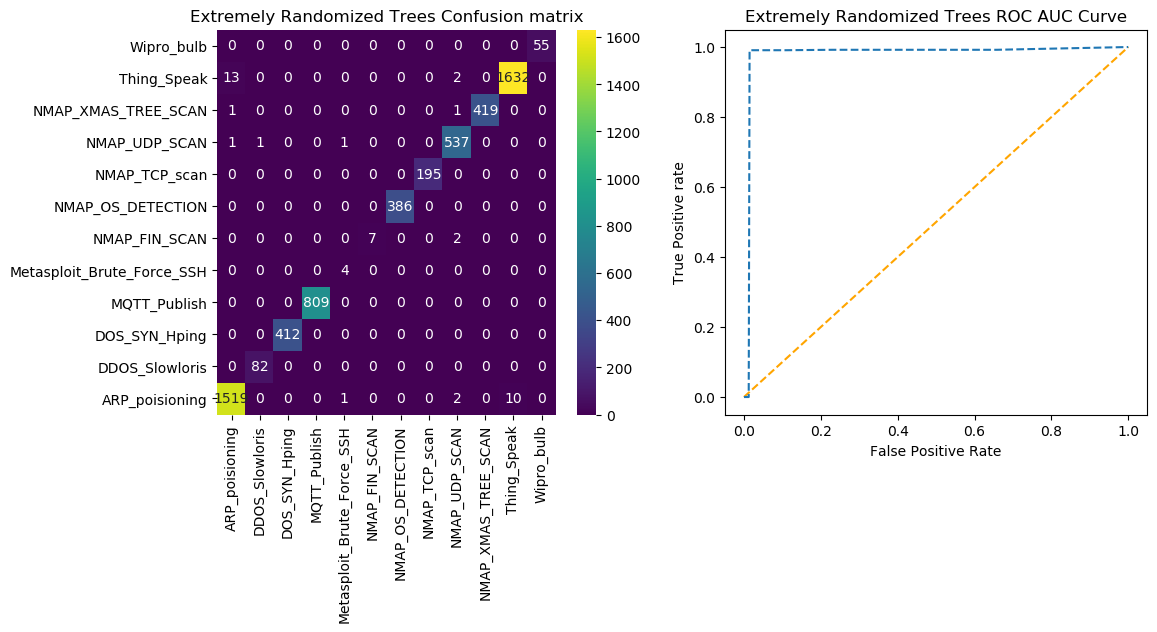

In [21]:
#train ERT algorithm on 80% training features and then apply trained model on 20% test to calculate prediction accuracy
ert_cls = ExtraTreesClassifier(n_estimators=100, criterion='gini', random_state=42)
#train model on training features
ert_cls.fit(X_train, y_train)
#call this function to predict on test data
predict = ert_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("Extremely Randomized Trees", y_test, predict)

 Hybrid Model Accuracy  : 99.458
 Hybrid Model Precision : 98.104
 Hybrid Model Recall    : 97.937
 Hybrid Model FSCORE    : 97.812


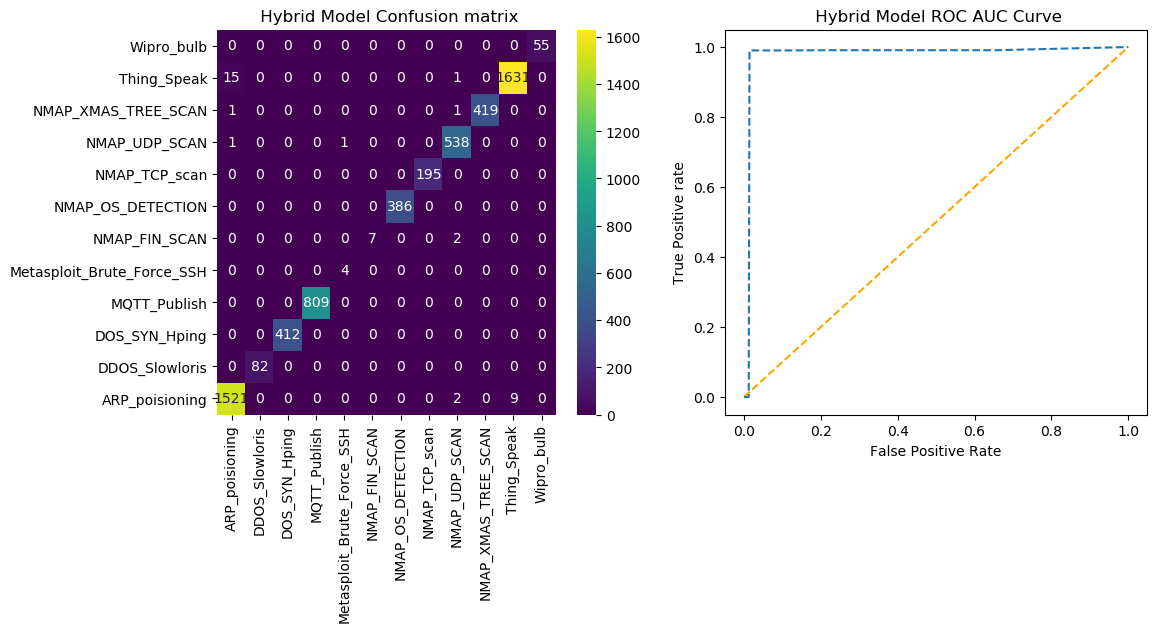

In [22]:
#applying features selection algorithm to select top relevant features
selector = SelectKBest(score_func=chi2, k=45) 
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)
#train Hybrid algorithm on 80% training features and then apply trained model on 20% test to calculate prediction accuracy
ada = AdaBoostClassifier()
er = ExtraTreesClassifier(n_estimators=100, criterion='gini', max_depth=50, random_state=42)
estimators = [('ert', er), ('ada', ada)]
hybrid_model = VotingClassifier(estimators = estimators, voting='soft')
#train model on training features
hybrid_model.fit(X_train, y_train)
#call this function to predict on test data
predict = hybrid_model.predict(X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation(" Hybrid Model", y_test, predict)

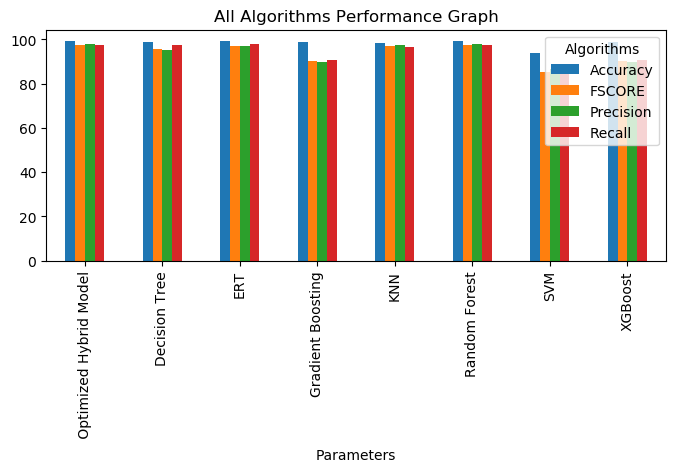

In [23]:
#plot all algorithm performance in tabukar format
df = pd.DataFrame([['KNN','Accuracy',accuracy[0]],['KNN','Precision',precision[0]],['KNN','Recall',recall[0]],['KNN','FSCORE',fscore[0]],
                   ['SVM','Accuracy',accuracy[1]],['SVM','Precision',precision[1]],['SVM','Recall',recall[1]],['SVM','FSCORE',fscore[1]],
                   ['Decision Tree','Accuracy',accuracy[2]],['Decision Tree','Precision',precision[2]],['Decision Tree','Recall',recall[2]],['Decision Tree','FSCORE',fscore[2]],
                   ['Gradient Boosting','Accuracy',accuracy[3]],['Gradient Boosting','Precision',precision[3]],['Gradient Boosting','Recall',recall[3]],['Gradient Boosting','FSCORE',fscore[3]],
                   ['XGBoost','Accuracy',accuracy[4]],['XGBoost','Precision',precision[4]],['XGBoost','Recall',recall[4]],['XGBoost','FSCORE',fscore[4]],
                   ['Random Forest','Accuracy',accuracy[5]],['Random Forest','Precision',precision[5]],['Random Forest','Recall',recall[5]],['Random Forest','FSCORE',fscore[5]],
                  
                   ['ERT','Accuracy',accuracy[6]],['ERT','Precision',precision[6]],['ERT','Recall',recall[6]],['ERT','FSCORE',fscore[6]],
                   [' Optimized Hybrid Model','Accuracy',accuracy[7]],[' Optimized Hybrid Model','Precision',precision[7]],[' Optimized Hybrid Model','Recall',recall[7]],[' Optimized Hybrid Model','FSCORE',fscore[7]],
                   
                  
                  
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar', figsize=(8, 3))
plt.title("All Algorithms Performance Graph")
plt.show()

In [24]:
#display all algorithm performnace
algorithms = ['KNN', 'SVM', 'Decsion Tree', 'Gradient Boosting', 'XGBoost', 'Random Forest', 'ERT', ' Features Optimized Hybrid Model']
data = []
for i in range(len(accuracy)):
    data.append([algorithms[i], accuracy[i], precision[i], recall[i], fscore[i]])
data = pd.DataFrame(data, columns=['Algorithm Name', 'Accuracy', 'Precision', 'Recall', 'FSCORE'])
data  

IndexError: list index out of range

In [26]:
#loading test data and then applying extension model to predict type of attack
testData = pd.read_csv("Dataset/testData.csv")#load test data
data = testData.values
for i in range(len(label_encoder)-1):#label encoding from non-numeric to numeric
    le = label_encoder[i]
    testData[le[0]] = pd.Series(le[1].transform(testData[le[0]].astype(str)))#encode all str columns to numeric
testData.fillna(dataset.mean(), inplace = True)#replace misisng values with mean    
testData = testData.values    
testData = scaler.transform(testData)#normalize test data
testData = selector.transform(testData)#select relevant features
predict = hybrid_model.predict(testData)#apply extension hybrid model to predict attack type
for i in range(len(predict)):
    print("Test Data = "+str(data[i])+" Predicted Attack Type ====> "+labels[predict[i]])
    print()

Test Data = [4838 21 'tcp' '-' 4e-06 1 1 1 0 246723.764706 246723.764706 493447.529412
 1.0 20 20 20 20 20 20 0 1 1 0 0 1 0 0 0 0 120.0 120.0 120.0 120.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0 120.0 120.0 60.0 84.852814 0.0 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 4.053116 4.053116 4.053116 4.053116 0.0 29606851.764706
 1.0 1.0 120.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 4.053116 4.053116 4.053116
 4.053116 0.0 0.0 0.0 0.0 0.0 0.0 64 0 64] Predicted Attack Type ====> DOS_SYN_Hping

Test Data = [50079 19632 'udp' '-' 0.0 1 0 0 0 0.0 0.0 0.0 0.0 8 8 8 0 0 0 0 0 0 0 0 0
 0 0 0 0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0 0 0] Predicted Attack Type ====> NMAP_UDP_SCAN

Test Data = [54300 1287 'tcp' '-' 4e-06 1 1 0 0 262144.0 262144.0 524288.0 1.0 40 40
 40 20 20 20 0 1 1 0 0 1 0 0 0 0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0 0.0 0.